In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS (same as before)
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45,12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74,12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03,12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76,12): "Data/ns176/abx12.arrow",

    (0.45, 0): "Data/ns045.arrow",
    (0.74, 0): "Data/ns074.arrow",
    (1.03, 0): "Data/ns103.arrow",
    (1.76, 0): "Data/ns176.arrow",
}




In [3]:
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})


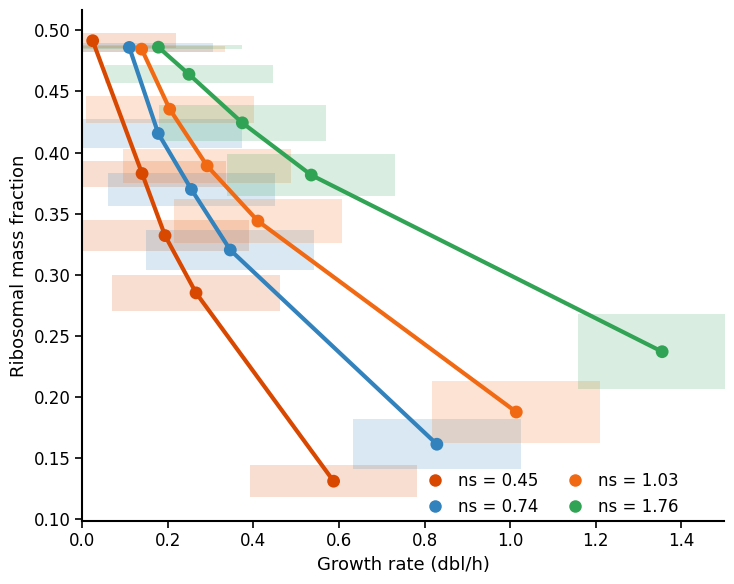

,ns,abx,lambda_mean,phiR_mean,phiR_std
16,0.45,0,0.587528,0.131129,0.013282
0,0.45,2,0.265989,0.285163,0.014709
1,0.45,4,0.193503,0.332038,0.012549
2,0.45,8,0.139867,0.382802,0.010611
3,0.45,12,0.024392,0.491456,0.006146
17,0.74,0,0.828869,0.161359,0.020535
4,0.74,2,0.346044,0.320263,0.016461
5,0.74,4,0.255191,0.369788,0.013596
6,0.74,8,0.177674,0.415582,0.012057
7,0.74,12,0.110068,0.485971,0.003419


In [10]:
# ============================================================
# Ribosomal mass fraction vs growth rate
# Nature-style visualization (FULL, ONE CELL)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
from statsmodels.nonparametric.smoothers_lowess import lowess

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

# FILES must be:
# FILES = {(ns, abx): "path/to/file.arrow", ...}

# ------------------------------------------------------------
# GLOBAL STYLE (paper-like)
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

# ------------------------------------------------------------
# COLOR PALETTE (close to reference)
# ------------------------------------------------------------
COLORS = [
    "#d94801",  # red-orange
    "#3182bd",  # blue
    "#f16913",  # orange
    "#31a354",  # green
    "#756bb1",  # purple
    "#2b8cbe",  # teal
]

# ------------------------------------------------------------
# I/O
# ------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# MODEL DEFINITIONS (UNCHANGED)
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    total     = ribo_mass + non_ribo
    return ribo_mass, total

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma

# ------------------------------------------------------------
# AGGREGATE PER (ns, abx)
# ------------------------------------------------------------
records = []

for (ns, abx), fn in FILES.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    ribo_mass, mass = compute_mass(df)
    ttrate = compute_ttrate(df, mass)

    lam = (ttrate / mass) * 60.0 / np.log(2.0)
    phiR = ribo_mass / mass

    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    lam = lam[valid]
    phiR = phiR[valid]

    records.append({
        "ns": ns,
        "abx": abx,
        "lambda_mean": lam.mean(),
        "phiR_mean": phiR.mean(),
        "phiR_std": phiR.std(),
    })

res = pd.DataFrame(records)

# ------------------------------------------------------------
# SMOOTHING HELPER
# ------------------------------------------------------------
def smooth_xy(x, y, frac=0.7):
    sm = lowess(y, x, frac=frac, return_sorted=True)
    return sm[:,0], sm[:,1]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 6))

for color, (ns, g) in zip(COLORS, res.groupby("ns")):
    g = g.sort_values("lambda_mean")

    # uncertainty boxes
    lam_std = lam.std()
    for x, y, s in zip(g["lambda_mean"], g["phiR_mean"], g["phiR_std"]):
        plt.fill_between(
            [x - lam_std, x + lam_std],
            y - s, y + s,
            color=color,
            alpha=0.18,
            linewidth=0
            )

    # smooth curve
    xs, ys = smooth_xy(g["lambda_mean"], g["phiR_mean"])
    plt.plot(xs, ys, color=color, lw=3)

    # scatter points
    plt.scatter(
        g["lambda_mean"],
        g["phiR_mean"],
        s=85,
        color=color,
        edgecolor="none",
        zorder=3
    )

# ------------------------------------------------------------
# ANNOTATIONS (as in reference)
# ------------------------------------------------------------
# plt.annotate(
#     "Antibiotic dose",
#     xy=(1.1, 0.52),
#     xytext=(2.1, 0.45),
#     arrowprops=dict(arrowstyle="->", lw=2, color="gray"),
#     color="gray",
#     fontsize=12
# )

# plt.annotate(
#     "Nutrient quality",
#     xy=(2.3, 0.33),
#     xytext=(0.9, 0.10),
#     arrowprops=dict(arrowstyle="->", lw=2, color="gray"),
#     color="gray",
#     fontsize=12
# )
from matplotlib.lines import Line2D

legend_elements = []

for color, ns in zip(COLORS, sorted(res["ns"].unique())):
    legend_elements.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markersize=9,
            markerfacecolor=color,
            markeredgecolor='none',
            label=f"ns = {ns:.2f}"
        )
    )


# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------
plt.xlabel("Growth rate (dbl/h)", fontsize=13)
plt.ylabel("Ribosomal mass fraction", fontsize=13)
plt.legend(
    handles=legend_elements,
    frameon=False,
    ncol=2,
    columnspacing=1.2,
    handletextpad=0.4,
    loc="lower left",
    bbox_to_anchor=(0.5, -0.02)
)

plt.xlim(0,1.5)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DEBUG TABLE
# ------------------------------------------------------------
display(res.sort_values(["ns", "abx"]))


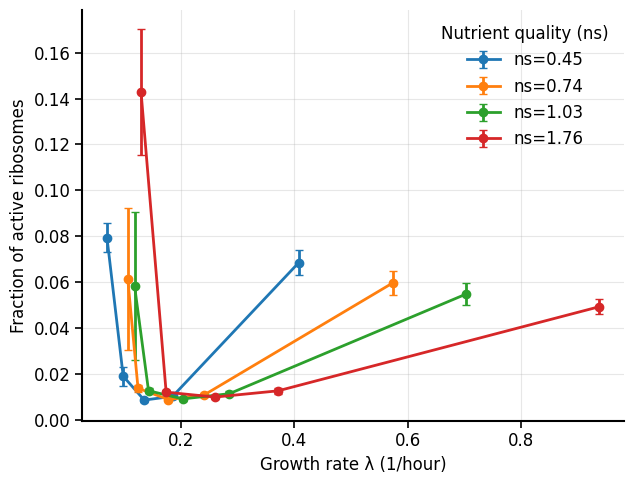

,ns,abx,lambda_mean,frac_active_mean,frac_active_std
16,0.45,0,0.407243,0.068452,0.005409
0,0.45,2,0.184369,0.010303,0.000878
1,0.45,4,0.134126,0.008682,0.000829
2,0.45,8,0.096949,0.019059,0.004067
3,0.45,12,0.068226,0.079395,0.006363
17,0.74,0,0.574528,0.059791,0.005177
4,0.74,2,0.239860,0.010868,0.000973
5,0.74,4,0.176885,0.008917,0.000785
6,0.74,8,0.123155,0.013829,0.001623
7,0.74,12,0.105009,0.061337,0.030818


In [25]:
# ============================================================
# FIGURE 2: Fraction of Active Ribosomes vs Growth Rate
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

# FILES must be:
# FILES = {(ns, abx): "Data/....arrow", ...}

# ------------------------------------------------------------
# I/O
# ------------------------------------------------------------
def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ------------------------------------------------------------
# MASS
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

# ------------------------------------------------------------
# FREE / ACTIVE RIBOSOMES (mass-normalized)
# ------------------------------------------------------------
def compute_free_active_ribosomes(df, mass):
    free = df["r(t)"].values / mass

    active = (
        df["rmm(t)"].values +
        df["rmt(t)"].values +
        df["rmq(t)"].values +
        df["rmr(t)"].values
    ) / mass

    # polysome correction (model-specific)
    # free   = free - 9.0 * active
    # active = 10.0 * active

    return free, active

# ------------------------------------------------------------
# TRANSLATION RATE → GROWTH RATE
# ------------------------------------------------------------
def compute_growth_rate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active_ribo = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    ttrate = active_ribo * gamma
    lam = (ttrate / mass) * 60.0   # 1/hour
    return lam

# ------------------------------------------------------------
# AGGREGATE PER (ns, abx)
# ------------------------------------------------------------
records = []

for (ns, abx), fn in FILES.items():
    df = read_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN].copy()

    mass = compute_mass(df)
    free, active = compute_free_active_ribosomes(df, mass)
    lam = compute_growth_rate(df, mass)

    total = free + active
    # valid = (total > 0) & (~np.isnan(lam))
    valid = (total > 1e-6) & (free >= 0) & (active >= 0)
    frac_active = active[valid] / total[valid]
    lam = lam[valid]

    records.append({
        "ns": ns,
        "abx": abx,
        "lambda_mean": lam.mean(),
        "frac_active_mean": frac_active.mean(),
        "frac_active_std": frac_active.std(),
    })

df_active = pd.DataFrame(records)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))

for ns, g in df_active.groupby("ns"):
    g = g.sort_values("lambda_mean")
    ax.errorbar(
        g["lambda_mean"],
        g["frac_active_mean"],
        yerr=g["frac_active_std"],
        fmt="o-",
        lw=2,
        capsize=3,
        label=f"ns={ns:.2f}"
    )

ax.set_xlabel("Growth rate λ (1/hour)")
ax.set_ylabel("Fraction of active ribosomes")
ax.grid(alpha=0.3)
ax.legend(frameon=False, title="Nutrient quality (ns)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DEBUG TABLE
# ------------------------------------------------------------
display(df_active.sort_values(["ns", "abx"]))


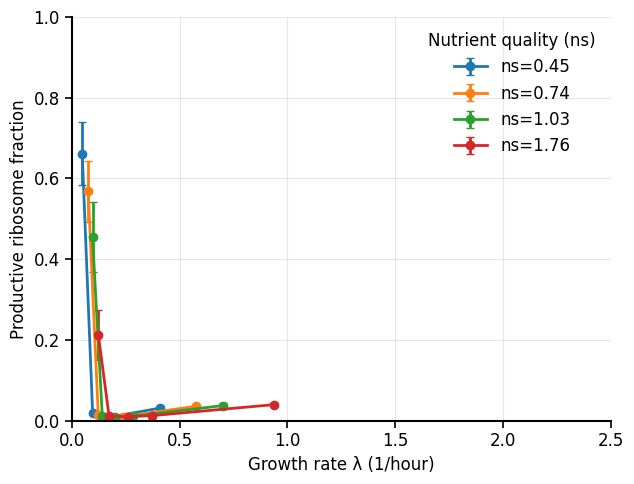

,ns,abx,lambda_mean,fprod_mean,fprod_std
16,0.45,0,0.407243,0.030933,0.005521
0,0.45,2,0.184369,0.009322,0.000958
1,0.45,4,0.134126,0.008203,0.000831
2,0.45,8,0.096949,0.018502,0.003892
3,0.45,12,0.048624,0.661814,0.077451
17,0.74,0,0.574528,0.035546,0.005573
4,0.74,2,0.239860,0.010164,0.001073
5,0.74,4,0.176885,0.008613,0.000804
6,0.74,8,0.123155,0.013592,0.001582
7,0.74,12,0.076293,0.567702,0.075904


In [26]:
# ============================================================
# FIGURE 2 (REVISED):
# Productive ribosome fraction vs growth rate
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

# FILES must be:
# FILES = {(ns, abx): "Data/....arrow", ...}

# ------------------------------------------------------------
# I/O
# ------------------------------------------------------------
def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ------------------------------------------------------------
# MASS
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

# ------------------------------------------------------------
# TOTAL RIBOSOMES (NO POLYSOME CORRECTION)
# ------------------------------------------------------------
def compute_total_ribosomes(df):
    return (
        df["r(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
        + df["rmr(t)"].to_numpy()
    )

# ------------------------------------------------------------
# TRANSLATION RATE
# ------------------------------------------------------------
def compute_translation_rate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active_ribo = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )

    return active_ribo * gamma

# ------------------------------------------------------------
# AGGREGATE PER (ns, abx)
# ------------------------------------------------------------
records = []

for (ns, abx), fn in FILES.items():
    df = read_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN].copy()

    mass = compute_mass(df)
    ttrate = compute_translation_rate(df, mass)

    total_ribo = compute_total_ribosomes(df)

    # Productive ribosome fraction (time-resolved)
    valid = total_ribo > 0
    f_prod = ttrate[valid] / (GMAX * total_ribo[valid])

    # Growth rate
    lam = (ttrate / mass) * 60.0
    lam = lam[valid]

    records.append({
        "ns": ns,
        "abx": abx,
        "lambda_mean": lam.mean(),
        "fprod_mean": f_prod.mean(),
        "fprod_std": f_prod.std(),
    })

df_prod = pd.DataFrame(records)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))

for ns, g in df_prod.groupby("ns"):
    g = g.sort_values("lambda_mean")

    ax.errorbar(
        g["lambda_mean"],
        g["fprod_mean"],
        yerr=g["fprod_std"],
        fmt="o-",
        lw=2,
        capsize=3,
        label=f"ns={ns:.2f}"
    )

ax.set_xlabel("Growth rate λ (1/hour)")
ax.set_ylabel("Productive ribosome fraction")
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.legend(frameon=False, title="Nutrient quality (ns)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DEBUG TABLE
# ------------------------------------------------------------
display(df_prod.sort_values(["ns", "abx"]))


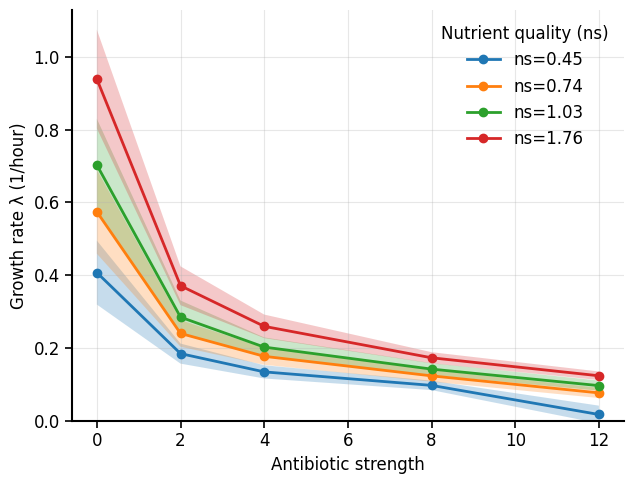

,ns,abx,lambda_mean,lambda_std
16,0.45,0,0.407243,0.087902
0,0.45,2,0.184369,0.027574
1,0.45,4,0.134126,0.018165
2,0.45,8,0.096949,0.012943
3,0.45,12,0.016907,0.024333
17,0.74,0,0.574528,0.115377
4,0.74,2,0.239860,0.036684
5,0.74,4,0.176885,0.023311
6,0.74,8,0.123155,0.015883
7,0.74,12,0.076293,0.014111


In [29]:
# ============================================================
# Growth rate vs antibiotic strength
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

# FILES must be:
# FILES = {(ns, abx): "Data/....arrow", ...}
FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45,12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74,12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03,12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76,12): "Data/ns176/abx12.arrow",

    (0.45, 0): "Data/ns045.arrow",
    (0.74, 0): "Data/ns074.arrow",
    (1.03, 0): "Data/ns103.arrow",
    (1.76, 0): "Data/ns176.arrow",
}

# ------------------------------------------------------------
# I/O
# ------------------------------------------------------------
def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ------------------------------------------------------------
# MASS
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

# ------------------------------------------------------------
# TRANSLATION RATE → GROWTH RATE
# ------------------------------------------------------------
def compute_growth_rate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active_ribo = (
        df["rmr(t)"].to_numpy()
        + df["rmt(t)"].to_numpy()
        + df["rmm(t)"].to_numpy()
        + df["rmq(t)"].to_numpy()
    )

    ttrate = active_ribo * gamma
    lam = (ttrate / mass) * 60.0   # 1/hour
    return lam

# ------------------------------------------------------------
# AGGREGATE PER (ns, abx)
# ------------------------------------------------------------
records = []

for (ns, abx), fn in FILES.items():
    df = read_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN].copy()

    mass = compute_mass(df)
    lam = compute_growth_rate(df, mass)

    lam = lam[~np.isnan(lam)]

    records.append({
        "ns": ns,
        "abx": abx,
        "lambda_mean": lam.mean(),
        "lambda_std": lam.std(),
    })

df_growth = pd.DataFrame(records)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))

for ns, g in df_growth.groupby("ns"):
    g = g.sort_values("abx")

    ax.plot(
    g["abx"],
    g["lambda_mean"],
    "-o",
    lw=2,
    label=f"ns={ns:.2f}"
)

    ax.fill_between(
    g["abx"],
    g["lambda_mean"] - g["lambda_std"],
    g["lambda_mean"] + g["lambda_std"],
    alpha=0.25
)


ax.set_xlabel("Antibiotic strength")
ax.set_ylabel("Growth rate λ (1/hour)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend(frameon=False, title="Nutrient quality (ns)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DEBUG TABLE
# ------------------------------------------------------------
display(df_growth.sort_values(["ns", "abx"]))


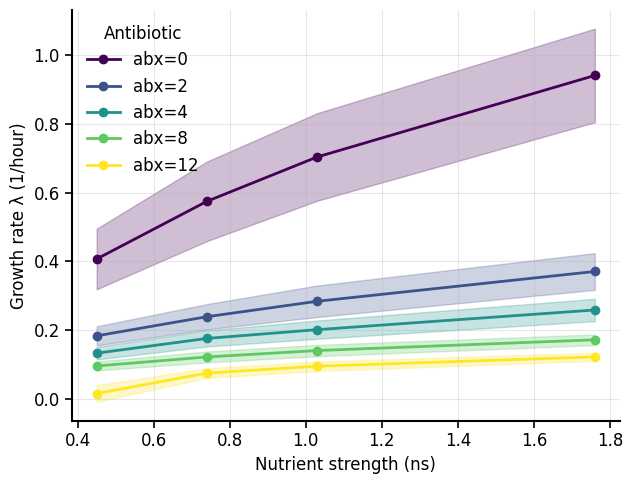

In [11]:
# ============================================================
# Growth rate vs nutrient strength (ns)
# with ±1 STD error shadows
# ============================================================

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------
FILES = {
    (0.45, 0): "Data/ns045.arrow", (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow", (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45,12): "Data/ns045/abx12.arrow",

    (0.74, 0): "Data/ns074.arrow", (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow", (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74,12): "Data/ns074/abx12.arrow",

    (1.03, 0): "Data/ns103.arrow", (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow", (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03,12): "Data/ns103/abx12.arrow",

    (1.76, 0): "Data/ns176.arrow", (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow", (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76,12): "Data/ns176/abx12.arrow",
}

NS_VALUES  = sorted({k[0] for k in FILES})
ABX_LEVELS = sorted({k[1] for k in FILES})

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    ribo = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )
    non_ribo = df["q(t)"] + df["et(t)"] + df["em(t)"]
    return NR * ribo.to_numpy() + NX * non_ribo.to_numpy()

def compute_growth_rate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)
    active = (
        df["rmr(t)"] + df["rmt(t)"] +
        df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()
    return (active * gamma / mass) * 60.0  # 1/hour

# ------------------------------------------------------------
# COMPUTE STATS
# ------------------------------------------------------------
records = []

for (ns, abx), fn in FILES.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    mass = compute_mass(df)
    lam  = compute_growth_rate(df, mass)

    records.append({
        "ns": ns,
        "abx": abx,
        "lam_mean": lam.mean(),
        "lam_std": lam.std(ddof=1),
    })

stats = pd.DataFrame(records)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(ABX_LEVELS)))

for color, abx in zip(colors, ABX_LEVELS):

    g = stats[stats["abx"] == abx].sort_values("ns")

    x = g["ns"].to_numpy()
    y = g["lam_mean"].to_numpy()
    e = g["lam_std"].to_numpy()

    ax.fill_between(x, y - e, y + e,
                    color=color, alpha=0.25)
    ax.plot(x, y, "-o", lw=2, color=color,
            label=f"abx={abx}")

ax.set_xlabel("Nutrient strength (ns)")
ax.set_ylabel("Growth rate λ (1/hour)")
ax.grid(alpha=0.3)
ax.legend(frameon=False, title="Antibiotic")

plt.tight_layout()
plt.show()


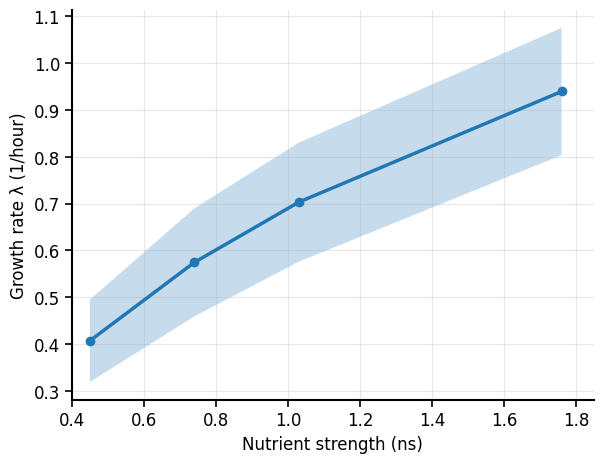

In [13]:
# ============================================================
# Growth rate vs nutrient strength (abx = 0 only)
# with ±1 STD error shadow
# x-axis tightened to highlight curvature
# ============================================================

import numpy as np
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# ------------------------------------------------------------
# FILES (abx = 0 only)
# ------------------------------------------------------------
FILES0 = {
    0.45: "Data/ns045.arrow",
    0.74: "Data/ns074.arrow",
    1.03: "Data/ns103.arrow",
    1.76: "Data/ns176.arrow",
}

NS_VALUES = np.array(sorted(FILES0.keys()))

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    ribo = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )
    non_ribo = df["q(t)"] + df["et(t)"] + df["em(t)"]
    return NR * ribo.to_numpy() + NX * non_ribo.to_numpy()

def compute_growth_rate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)
    active = (
        df["rmr(t)"] + df["rmt(t)"] +
        df["rmm(t)"] + df["rmq(t)"]
    ).to_numpy()
    return (active * gamma / mass) * 60.0  # 1/hour

# ------------------------------------------------------------
# COMPUTE STATS
# ------------------------------------------------------------
lam_mean = []
lam_std  = []

for ns in NS_VALUES:
    df = load_arrow(FILES0[ns])
    df = df[df["timestamp"] >= BURN_IN]

    mass = compute_mass(df)
    lam  = compute_growth_rate(df, mass)

    lam_mean.append(lam.mean())
    lam_std.append(lam.std(ddof=1))

lam_mean = np.array(lam_mean)
lam_std  = np.array(lam_std)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 4.8))

ax.fill_between(
    NS_VALUES,
    lam_mean - lam_std,
    lam_mean + lam_std,
    alpha=0.25
)
ax.plot(NS_VALUES, lam_mean, "-o", lw=2.5)

ax.set_xlabel("Nutrient strength (ns)")
ax.set_ylabel("Growth rate λ (1/hour)")
ax.grid(alpha=0.3)

# ---- tighten x-axis (THIS is the key line) ----
ax.set_xlim(0.4, 1.85)

plt.tight_layout()
plt.show()
